In [25]:
import pandas as pd
import json
# plotting
import os
import pathlib
import warnings
from joblib import load
from mplsoccer import Pitch
from itertools import combinations_with_replacement
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [7]:
df = pd.DataFrame()
for i in range(11):
    file_name = 'possession_chains_England' + str(i+1) + '.json'
    path = os.path.join(str(pathlib.Path().resolve().parents[0]), 'data', 'possession_chain', file_name)
    with open(path) as f:
        data = json.load(f)
    df = pd.concat([df, pd.DataFrame(data)], ignore_index = True)
df = df.reset_index()
df

,level_0,index,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,...,possesion_chain,possesion_chain_team,xG,shot_end,x0,c0,x1,c1,y0,y1
0,0,0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,...,0,1609,0.000000,0,51.45,0.68,32.55,19.04,34.68,14.96
1,1,1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,...,0,1609,0.000000,0,32.55,19.04,53.55,17.00,14.96,17.00
2,2,2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,...,0,1609,0.000000,0,53.55,17.00,36.75,14.28,17.00,19.72
3,3,3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,...,0,1609,0.000000,0,36.75,14.28,43.05,30.60,19.72,3.40
4,4,4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,...,0,1609,0.000000,0,43.05,30.60,75.60,25.84,3.40,8.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435129,435129,43142,8,High pass,[{'id': 1801}],20620,"[{'y': 89, 'x': 53}, {'y': 72, 'x': 99}]",2500098,Pass,1633,...,113381,1633,0.000000,0,55.65,26.52,103.95,14.96,7.48,19.04
435130,435130,43143,8,Cross,"[{'id': 402}, {'id': 2101}, {'id': 1802}]",14703,"[{'y': 72, 'x': 99}, {'y': 0, 'x': 0}]",2500098,Pass,1633,...,113381,1633,0.000000,0,103.95,14.96,0.00,34.00,19.04,68.00
435131,435131,43146,3,Corner,"[{'id': 302}, {'id': 801}, {'id': 1801}]",70965,"[{'y': 100, 'x': 100}, {'y': 47, 'x': 88}]",2500098,Free Kick,1633,...,113382,1633,0.038676,1,105.00,34.00,92.40,2.04,0.00,36.04
435132,435132,43148,1,Air duel,"[{'id': 703}, {'id': 1801}]",8005,"[{'y': 47, 'x': 88}, {'y': 50, 'x': 86}]",2500098,Duel,1633,...,113382,1633,0.038676,1,92.40,2.04,90.30,0.00,36.04,34.00


In [16]:
#model variables
var = ["x0", "x1", "c0", "c1"]

#combinations
inputs = []
#one variable combinations
inputs.extend(combinations_with_replacement(var, 1))
#2 variable combinations
inputs.extend(combinations_with_replacement(var, 2))
#3 variable combinations
inputs.extend(combinations_with_replacement(var, 3))
inputs

[('x0',),
 ('x1',),
 ('c0',),
 ('c1',),
 ('x0', 'x0'),
 ('x0', 'x1'),
 ('x0', 'c0'),
 ('x0', 'c1'),
 ('x1', 'x1'),
 ('x1', 'c0'),
 ('x1', 'c1'),
 ('c0', 'c0'),
 ('c0', 'c1'),
 ('c1', 'c1'),
 ('x0', 'x0', 'x0'),
 ('x0', 'x0', 'x1'),
 ('x0', 'x0', 'c0'),
 ('x0', 'x0', 'c1'),
 ('x0', 'x1', 'x1'),
 ('x0', 'x1', 'c0'),
 ('x0', 'x1', 'c1'),
 ('x0', 'c0', 'c0'),
 ('x0', 'c0', 'c1'),
 ('x0', 'c1', 'c1'),
 ('x1', 'x1', 'x1'),
 ('x1', 'x1', 'c0'),
 ('x1', 'x1', 'c1'),
 ('x1', 'c0', 'c0'),
 ('x1', 'c0', 'c1'),
 ('x1', 'c1', 'c1'),
 ('c0', 'c0', 'c0'),
 ('c0', 'c0', 'c1'),
 ('c0', 'c1', 'c1'),
 ('c1', 'c1', 'c1')]

In [10]:
#make new columns
for i in inputs:
    #columns length 1 already exist
    if len(i) > 1:
        #column name
        column = ''
        x = 1
        for c in i:
            #add column name to be x0x1c0 for example
            column += c
            #multiply values in column
            x = x*df[c]
        #create a new column in df
        df[column] = x
        #add column to model variables
        var.append(column)
#investigate 3 columns
df.head(3)

,level_0,index,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,...,x1x1x1,x1x1c0,x1x1c1,x1c0c0,x1c0c1,x1c1c1,c0c0c0,c0c0c1,c0c1c1,c1c1c1
0,0,0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,...,34486.806375,720.4617,20172.9276,15.05112,421.43136,11800.07808,0.314432,8.804096,246.514688,6902.411264
1,1,1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,...,153560.113875,54599.1516,48749.2425,19413.03168,17333.06400,15475.95000,6902.411264,6162.867200,5502.560000,4913.000000
2,2,2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,...,49633.171875,22959.5625,19286.0325,10620.75000,8921.43000,7494.00120,4913.000000,4126.920000,3466.612800,2911.954752


In [26]:
### TRAINING, it's not perfect ML procedure, but results in AUC 0.2 higher than Logistic Regression ###
passes = df.loc[ df["eventName"].isin(["Pass"])]
X = passes[var].values
y = passes["shot_end"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 123, stratify = y)
xgb = XGBClassifier(n_estimators = 100, ccp_alpha=0, max_depth=4, min_samples_leaf=10,
                      random_state=123)

scores = cross_val_score(estimator = xgb, X = X_train, y = y_train, cv = 10, n_jobs = -1)
print(np.mean(scores), np.std(scores))
xgb.fit(X_train, y_train)
print(xgb.score(X_train, y_train))
y_pred = xgb.predict(X_test)
print(xgb.score(X_test, y_test))

/home/ganesh/envs/soccer/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [09:17:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "ccp_alpha", "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ganesh/envs/soccer/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [09:17:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "ccp_alpha", "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ganesh/envs/soccer/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [09:17:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "ccp_alpha", "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ganesh/envs/soccer/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [09:17:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "ccp_alpha", "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=o

0.9204136735284447 0.0001524977377495358
0.9206947234892651
0.9205974842767296


In [31]:
passes = df.loc[df["eventName"].isin(["Pass"])]
X = passes[var].values
y = passes["shot_end"].values
#path to saved model
path_model = os.path.join(str(pathlib.Path().resolve().parents[0]), 'possession_chain', 'finalized_model.sav')
#predict probability of shot ended
y_pred_proba = xgb.predict_proba(X)[::,1]
passes["shot_prob"] = y_pred_proba
#OLS
shot_ended = passes.loc[passes["shot_end"] == 1]
X2 = shot_ended[var].values
y2 = shot_ended["xG"].values
lr = LinearRegression()
lr.fit(X2, y2)
y_pred = lr.predict(X)
passes["xG_pred"] = y_pred
#calculate xGchain
passes["xT"] = passes["xG_pred"]*passes["shot_prob"]
passes

,level_0,index,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,...,x1c0c0,x1c0c1,x1c1c1,c0c0c0,c0c0c1,c0c1c1,c1c1c1,shot_prob,xG_pred,xT
0,0,0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,...,15.05112,421.43136,11800.07808,0.314432,8.804096,246.514688,6902.411264,0.026900,0.085906,0.002311
1,1,1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,...,19413.03168,17333.06400,15475.95000,6902.411264,6162.867200,5502.560000,4913.000000,0.044499,0.097219,0.004326
2,2,2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,...,10620.75000,8921.43000,7494.00120,4913.000000,4126.920000,3466.612800,2911.954752,0.044126,0.090330,0.003986
3,3,3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,...,8778.68712,18811.47240,40310.29800,2911.954752,6239.903040,13371.220800,28652.616000,0.034288,0.086398,0.002962
4,4,4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,...,70788.81600,59777.22240,50478.54336,28652.616000,24195.542400,20431.791360,17253.512704,0.032493,0.105522,0.003429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435123,435123,43134,8,Simple pass,[{'id': 1801}],8313,"[{'y': 63, 'x': 65}, {'y': 96, 'x': 61}]",2500098,Pass,1633,...,5005.22568,17710.79856,62668.97952,690.807104,2444.394368,8649.395456,30605.553152,0.071657,0.097839,0.007011
435124,435124,43135,8,Simple pass,[{'id': 1801}],379209,"[{'y': 96, 'x': 61}, {'y': 85, 'x': 40}]",2500098,Pass,1633,...,41094.41280,31267.48800,23790.48000,30605.553152,23286.833920,17718.243200,13481.272000,0.055522,0.089775,0.004984
435128,435128,43141,8,Simple pass,[{'id': 1801}],8561,"[{'y': 70, 'x': 59}, {'y': 89, 'x': 53}]",2500098,Pass,1633,...,10293.02400,20071.39680,39139.22376,2515.456000,4905.139200,9565.021440,18651.791808,0.048478,0.095320,0.004621
435129,435129,43142,8,High pass,[{'id': 1801}],20620,"[{'y': 89, 'x': 53}, {'y': 72, 'x': 99}]",2500098,Pass,1633,...,73109.11608,41241.03984,23264.17632,18651.791808,10521.523584,5935.218432,3348.071936,0.034463,0.124809,0.004301


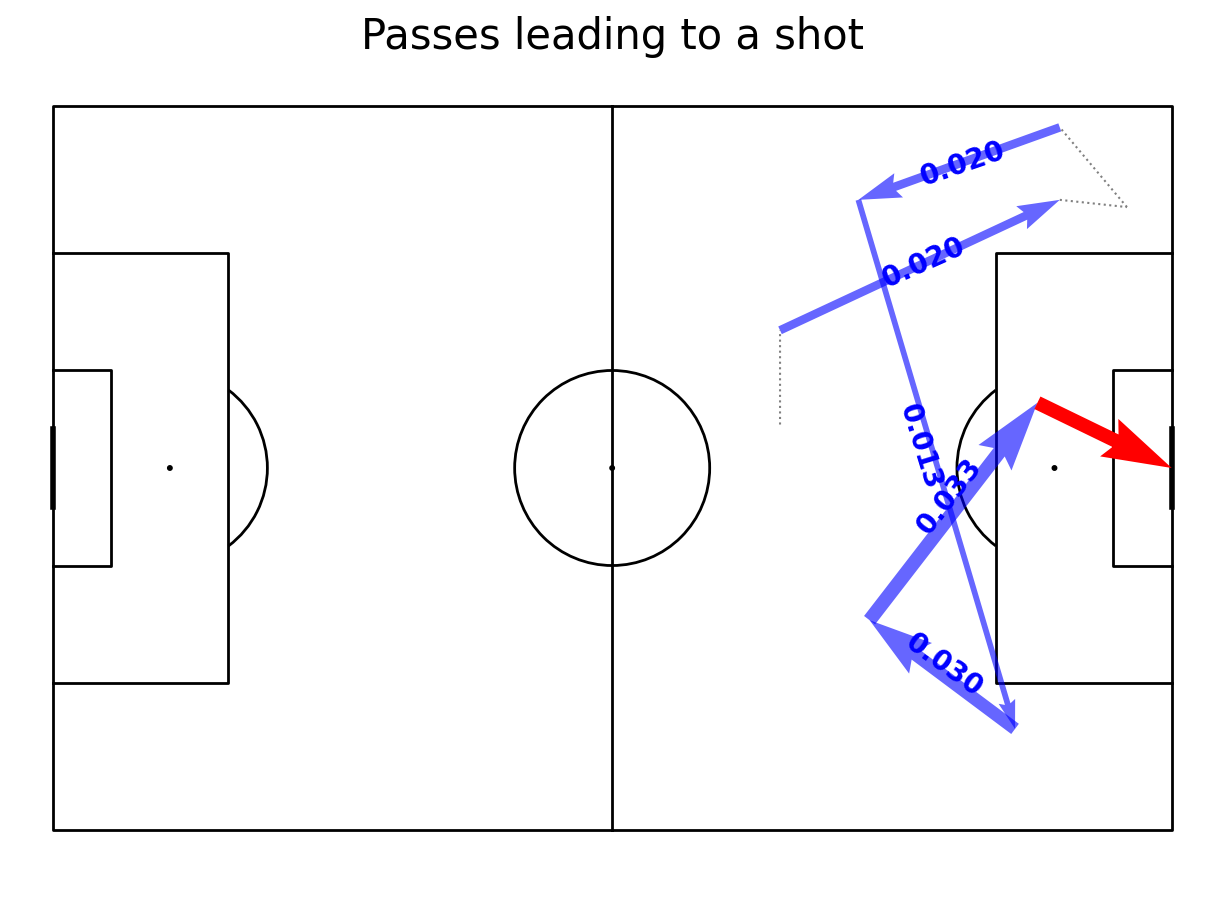

In [32]:
chain = df.loc[df["possesion_chain"] == 4]
#get passes
passes_in = passes.loc[df["possesion_chain"] == 4]
max_value = passes_in["xT"].max()
#get events different than pass
not_pass = chain.loc[chain["eventName"] != "Pass"].iloc[:-1]
#shot is the last event of the chain (or should be)
shot = chain.iloc[-1]
#plot
pitch = Pitch(line_color='black',pitch_type='custom', pitch_length=105, pitch_width=68, line_zorder = 2)
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#add size adjusted arrows
for i, row in passes_in.iterrows():
    value = row["xT"]
    #adjust the line width so that the more passes, the wider the line
    line_width = (value / max_value * 10)
    #get angle
    angle = np.arctan((row.y1-row.y0)/(row.x1-row.x0))*180/np.pi
    #plot lines on the pitch
    pitch.arrows(row.x0, row.y0, row.x1, row.y1,
                        alpha=0.6, width=line_width, zorder=2, color="blue", ax = ax["pitch"])
    #annotate text
    ax["pitch"].text((row.x0+row.x1-8)/2, (row.y0+row.y1-4)/2, str(value)[:5], fontweight = "bold", color = "blue", zorder = 4, fontsize = 20, rotation = int(angle))

#shot
pitch.arrows(shot.x0, shot.y0,
            shot.x1, shot.y1, width=line_width, color = "red", ax=ax['pitch'], zorder =  3)
#other passes like arrows
pitch.lines(not_pass.x0, not_pass.y0, not_pass.x1, not_pass.y1, color = "grey", lw = 1.5, ls = 'dotted', ax=ax['pitch'])
ax['title'].text(0.5, 0.5, 'Passes leading to a shot', ha='center', va='center', fontsize=30)
plt.show()

In [35]:
summary = passes[["playerId", "xT"]].groupby(["playerId"]).sum().reset_index()
#add player name
path = pathlib.Path('/home/ganesh/soccermatics/data/wyscout/players.json')
player_df = pd.read_json(path, encoding='unicode-escape')
player_df.rename(columns = {'wyId':'playerId'}, inplace=True)
player_df["role"] = player_df.apply(lambda x: x.role["name"], axis = 1)
to_merge = player_df[['playerId', 'shortName', 'role']]

summary = summary.merge(to_merge, how = "left", on = ["playerId"])
summary

,playerId,xT,shortName,role
0,0,0.029363,NaN,NaN
1,36,5.197927,T. Alderweireld,Defender
2,38,1.788936,D. Blind,Defender
3,48,12.797738,J. Vertonghen,Defender
4,54,25.774436,C. Eriksen,Midfielder
...,...,...,...,...
509,448708,0.065615,H. Barnes,Midfielder
510,450826,0.246086,C. Hudson-Odoi,Midfielder
511,486252,1.565598,A. Wan-Bissaka,Defender
512,531655,0.105841,L. Lumeka,Forward


In [36]:
#get minutes
path = pathlib.Path('/home/ganesh/soccermatics/data/minutes_played_per_game_England.json')
with open(path) as f:
    minutes_per_game = json.load(f)
#filtering over 400 per game
minutes_per_game = pd.DataFrame(minutes_per_game)
minutes = minutes_per_game.groupby(["playerId"]).minutesPlayed.sum().reset_index()
summary = minutes.merge(summary, how = "left", on = ["playerId"])
summary = summary.fillna(0)
summary = summary.loc[summary["minutesPlayed"] > 400]
#calculating per 90
summary["xT_p90"] = summary["xT"]*90/summary["minutesPlayed"]
summary

,playerId,minutesPlayed,xT,shortName,role,xT_p90
0,36,1238,5.197927,T. Alderweireld,Defender,0.377878
2,48,3343,12.797738,J. Vertonghen,Defender,0.344540
3,54,3348,25.774436,C. Eriksen,Midfielder,0.692861
5,74,1514,5.563492,R. Klavan,Defender,0.330723
6,93,2942,8.378604,J. Guðmunds­son,Midfielder,0.256314
...,...,...,...,...,...,...
491,397178,1904,7.533904,M. Rashford,Forward,0.356119
500,419784,405,0.956982,H. Choudhury,Midfielder,0.212663
502,434159,561,1.395085,S. Field,Midfielder,0.223810
508,447812,499,0.938669,T. Edwards,Defender,0.169299


In [37]:
#adjusting for possesion
path = pathlib.Path('/home/ganesh/soccermatics/data/player_possesion_England.json')
with open(path) as f:
    percentage_df = json.load(f)
percentage_df = pd.DataFrame(percentage_df)
#merge it
summary = summary.merge(percentage_df, how = "left", on = ["playerId"])
#adjust per possesion
summary["xT_adjusted_per_90"] = (summary["xT"]/summary["possesion"])*90/summary["minutesPlayed"]
summary

,playerId,minutesPlayed,xT,shortName,role,xT_p90,possesion,xT_adjusted_per_90
0,36,1238,5.197927,T. Alderweireld,Defender,0.377878,0.597434,0.632502
1,48,3343,12.797738,J. Vertonghen,Defender,0.344540,0.597295,0.576833
2,54,3348,25.774436,C. Eriksen,Midfielder,0.692861,0.606674,1.142065
3,74,1514,5.563492,R. Klavan,Defender,0.330723,0.592251,0.558417
4,93,2942,8.378604,J. Guðmunds­son,Midfielder,0.256314,0.438288,0.584807
...,...,...,...,...,...,...,...,...
392,397178,1904,7.533904,M. Rashford,Forward,0.356119,0.552620,0.644421
393,419784,405,0.956982,H. Choudhury,Midfielder,0.212663,0.520446,0.408616
394,434159,561,1.395085,S. Field,Midfielder,0.223810,0.402257,0.556386
395,447812,499,0.938669,T. Edwards,Defender,0.169299,0.420026,0.403068


In [38]:
summary[['shortName', 'xT_adjusted_per_90']].sort_values(by='xT_adjusted_per_90', ascending=False).head(10)

,shortName,xT_adjusted_per_90
22,M. Özil,1.606138
27,Fàbregas,1.481665
250,E. Hazard,1.433149
30,A. Sánchez,1.363377
117,David Silva,1.320920
39,Philippe Coutinho,1.242769
351,O. Zinchenko,1.240768
271,K. De Bruyne,1.237971
68,P. Pogba,1.219738
277,G. Xhaka,1.171086
